In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Libraries loaded
TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# Load the merged dataset
df = pd.read_csv('/content/final_dataset_2022_2024.csv', index_col=0)
df.index = pd.to_datetime(df.index, dayfirst=True)
df = df.sort_index()

print("Dataset loaded")
print(f"Rows: {df.shape[0]}")
print(f"From: {df.index.min().date()}")
print(f"To:   {df.index.max().date()}")

Dataset loaded
Rows: 52461
From: 2022-01-01
To:   2024-12-31


In [ ]:
# Load the trained LSTM model
lstm_model = load_model('/content/lstm_model.keras')

print("LSTM model loaded successfully")
lstm_model.summary()

LSTM model loaded successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,397 (403.90 KB)

 Trainable params: 34,465 (134.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68,932 (269.27 KB)

In [ ]:
# Define the feature set matching the LSTM's training input
feature_cols = [
    'demand_mw',
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos'
]

data = df[feature_cols].dropna()

train_data = data[data.index.year.isin([2022, 2023])]
test_data  = data[data.index.year == 2024]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print(f"Training rows: {len(train_scaled):,}")
print(f"Test rows:     {len(test_scaled):,}")
print("Data scaled successfully")

Training rows: 35,011
Test rows:     17,450
Data scaled successfully


In [ ]:
# Rebuild the 48-step sequences and extract LSTM embeddings
SEQ_LEN = 48

def create_sequences(data, sequence_length=48):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_seq, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test_seq,  y_test  = create_sequences(test_scaled,  SEQ_LEN)

# Run one prediction first so the model builds its internal graph
_ = lstm_model.predict(X_train_seq[:1], verbose=0)

# Now extract the LSTM hidden state layer
from tensorflow.keras.models import Model

embedding_model = Model(
    inputs  = lstm_model.inputs,
    outputs = lstm_model.layers[-3].output
)

train_embeddings = embedding_model.predict(X_train_seq, verbose=0)
test_embeddings  = embedding_model.predict(X_test_seq,  verbose=0)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape:  {test_embeddings.shape}")
print("LSTM embeddings extracted successfully")

Train embeddings shape: (34963, 32)
Test embeddings shape:  (17402, 32)
LSTM embeddings extracted successfully


In [ ]:
# Structured features for XGBoost
xgb_feature_cols = [
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_24h_mean'
]

# Align with sequence length offset
train_structured = df[xgb_feature_cols].loc[train_data.index[SEQ_LEN:]].values
test_structured  = df[xgb_feature_cols].loc[test_data.index[SEQ_LEN:]].values

# Combine LSTM embeddings with structured features
X_train_hybrid = np.hstack([train_embeddings, train_structured])
X_test_hybrid  = np.hstack([test_embeddings,  test_structured])

print(f"Hybrid training input shape: {X_train_hybrid.shape}")
print(f"Hybrid test input shape:     {X_test_hybrid.shape}")
print("Hybrid features combined successfully")

Hybrid training input shape: (34963, 55)
Hybrid test input shape:     (17402, 55)
Hybrid features combined successfully


In [ ]:
# Train the hybrid XGBoost regressor on embeddings + structured features
hybrid_model = xgb.XGBRegressor(
    n_estimators  = 500,
    learning_rate = 0.05,
    max_depth     = 6,
    random_state  = 42,
    verbosity     = 0
)

hybrid_model.fit(X_train_hybrid, y_train)

print("Hybrid XGBoost layer trained successfully")

Hybrid XGBoost layer trained successfully


In [ ]:
# Generate predictions and inverse-transform to MW
predictions_scaled = hybrid_model.predict(X_test_hybrid)

dummy_pred   = np.zeros((len(predictions_scaled), len(feature_cols)))
dummy_actual = np.zeros((len(y_test), len(feature_cols)))

dummy_pred[:, 0]   = predictions_scaled
dummy_actual[:, 0] = y_test

predictions_mw = scaler.inverse_transform(dummy_pred)[:, 0]
actual_mw      = scaler.inverse_transform(dummy_actual)[:, 0]

test_index = test_data.index[SEQ_LEN:]

results = pd.DataFrame({
    'actual'            : actual_mw,
    'predicted'         : predictions_mw,
    'event_flag'        : test_data['event_flag'].values[SEQ_LEN:],
    'is_public_holiday' : test_data['is_public_holiday'].values[SEQ_LEN:]
}, index=test_index)

print(f"Predictions made: {len(results):,}")

Predictions made: 17,402


In [ ]:
# Compute overall and event/non-event RMSE and MAE
overall_rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
overall_mae  = mean_absolute_error(results['actual'], results['predicted'])

event    = results[results['event_flag'] == 1]
nonevent = results[results['event_flag'] == 0]

event_rmse    = np.sqrt(mean_squared_error(event['actual'], event['predicted']))
event_mae     = mean_absolute_error(event['actual'], event['predicted'])
nonevent_rmse = np.sqrt(mean_squared_error(nonevent['actual'], nonevent['predicted']))
nonevent_mae  = mean_absolute_error(nonevent['actual'], nonevent['predicted'])

print("Hybrid LSTM-XGBoost Performance on 2024 Test Set")
print(f"\nOverall RMSE: {round(overall_rmse, 2)} MW")
print(f"Overall MAE:  {round(overall_mae, 2)} MW")
print(f"\nEvent days RMSE: {round(event_rmse, 2)} MW")
print(f"Event days MAE:  {round(event_mae, 2)} MW")
print(f"\nNon-event days RMSE: {round(nonevent_rmse, 2)} MW")
print(f"Non-event days MAE:  {round(nonevent_mae, 2)} MW")

Hybrid LSTM-XGBoost Performance on 2024 Test Set

Overall RMSE: 47.56 MW
Overall MAE:  34.83 MW

Event days RMSE: 41.81 MW
Event days MAE:  32.49 MW

Non-event days RMSE: 47.91 MW
Non-event days MAE:  34.99 MW


In [ ]:
# Load the baseline model's predictions for comparison
baseline = pd.read_csv('/content/baseline_predictions.csv', index_col=0)
baseline.index = pd.to_datetime(baseline.index)

baseline_rmse = np.sqrt(mean_squared_error(baseline['actual'], baseline['predicted']))
baseline_mae  = mean_absolute_error(baseline['actual'], baseline['predicted'])

b_event    = baseline[baseline['event_flag'] == 1]
b_nonevent = baseline[baseline['event_flag'] == 0]
b_event_rmse    = np.sqrt(mean_squared_error(b_event['actual'], b_event['predicted']))
b_nonevent_rmse = np.sqrt(mean_squared_error(b_nonevent['actual'], b_nonevent['predicted']))

print("=" * 55)
print(f"{'Metric':<25} {'XGBoost':>8} {'LSTM':>8} {'Hybrid':>8}")
print("=" * 55)
print(f"{'Overall RMSE (MW)':<25} {round(baseline_rmse,1):>8} {56.0:>8} {round(overall_rmse,1):>8}")
print(f"{'Overall MAE (MW)':<25} {round(baseline_mae,1):>8} {42.6:>8} {round(overall_mae,1):>8}")
print(f"{'Event RMSE (MW)':<25} {round(b_event_rmse,1):>8} {52.2:>8} {round(event_rmse,1):>8}")
print(f"{'Non-Event RMSE (MW)':<25} {round(b_nonevent_rmse,1):>8} {56.2:>8} {round(nonevent_rmse,1):>8}")
print("=" * 55)

Metric                     XGBoost     LSTM   Hybrid
Overall RMSE (MW)            116.7     56.0     47.6
Overall MAE (MW)              88.5     42.6     34.8
Event RMSE (MW)               98.6     52.2     41.8
Non-Event RMSE (MW)          117.7     56.2     47.9


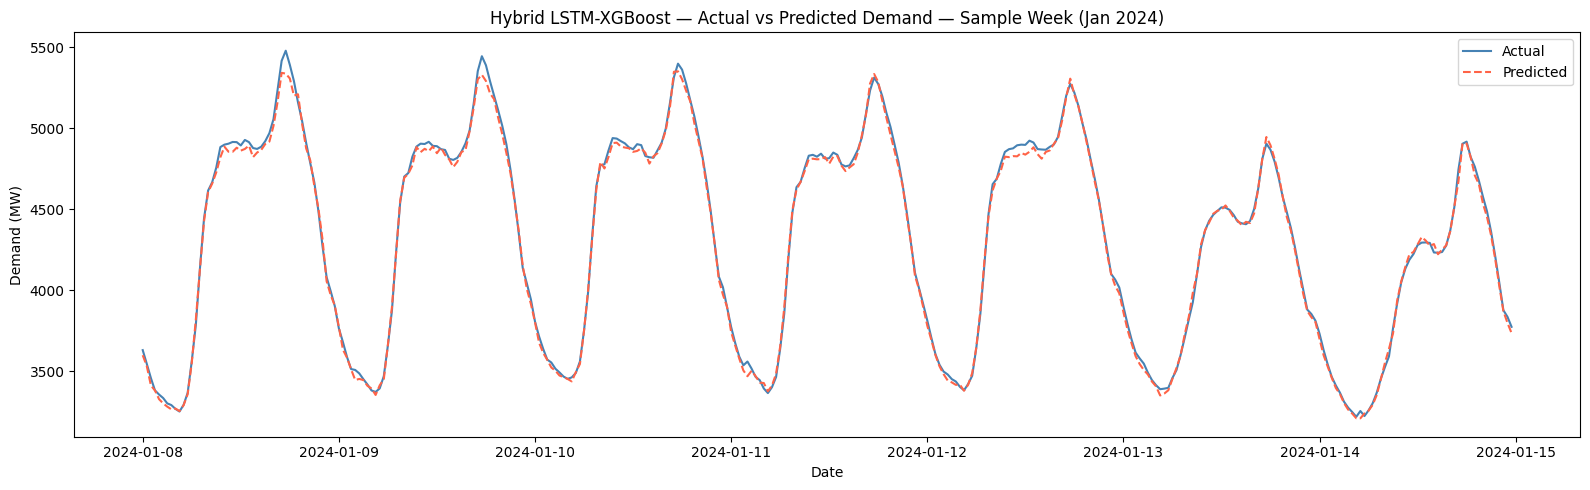

In [ ]:
# Plot actual vs predicted demand for a sample week
sample = results['2024-01-08':'2024-01-14']

plt.figure(figsize=(16, 5))
plt.plot(sample.index, sample['actual'],    color='steelblue', linewidth=1.5, label='Actual')
plt.plot(sample.index, sample['predicted'], color='tomato',    linewidth=1.5, label='Predicted', linestyle='--')
plt.title('Hybrid LSTM-XGBoost — Actual vs Predicted Demand — Sample Week (Jan 2024)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step5_chart1_sample_week.png', dpi=150)
plt.show()

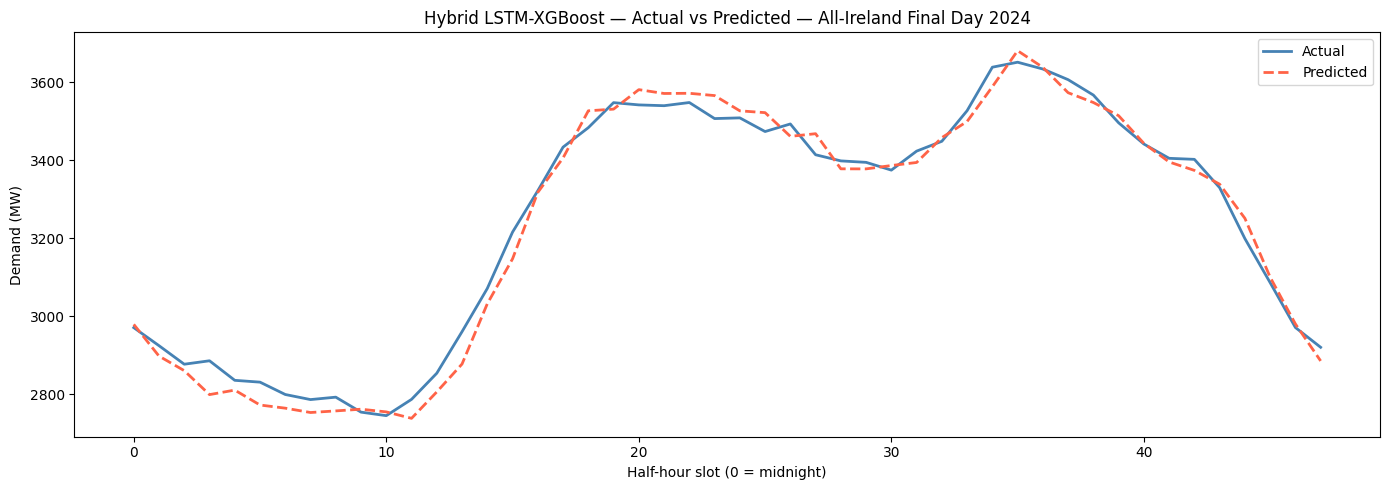

In [ ]:
# Plot actual vs predicted demand for the event case study day
event_date = pd.Timestamp('2024-07-28')
event_day  = results[results.index.date == event_date.date()]

plt.figure(figsize=(14, 5))
plt.plot(range(len(event_day)), event_day['actual'],    color='steelblue', linewidth=2, label='Actual')
plt.plot(range(len(event_day)), event_day['predicted'], color='tomato',    linewidth=2, label='Predicted', linestyle='--')
plt.title('Hybrid LSTM-XGBoost — Actual vs Predicted — All-Ireland Final Day 2024')
plt.xlabel('Half-hour slot (0 = midnight)')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step5_chart2_event_day.png', dpi=150)
plt.show()

In [ ]:
# Save the trained hybrid model and predictions
hybrid_model.save_model('/content/hybrid_model.json')
results.to_csv('/content/hybrid_predictions.csv')

print("Hybrid model saved: hybrid_model.json")
print("Predictions saved:  hybrid_predictions.csv")
print("Step 5 complete")

Hybrid model saved: hybrid_model.json
Predictions saved:  hybrid_predictions.csv
Step 5 complete
